Load Cleaned Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load cleaned datasets
recovery_df = pd.read_csv('recovery_data.csv')
eda_df = pd.read_csv('cleaned_eda_data.csv')

# Preview
print(recovery_df.head())
print("\nEDA Data Shape:", eda_df.shape)
print("Recovery Data Shape:", recovery_df.shape)

   id     sex  birth_year country               region group  \
0   1  female      1984.0   China  filtered at airport   NaN   
1   2    male      1964.0   Korea  filtered at airport   NaN   
2   3    male      1966.0   Korea         capital area   NaN   
3   4    male      1964.0   Korea         capital area   NaN   
4   6    male      1964.0   Korea         capital area   NaN   

       infection_reason  infection_order  infected_by  contact_number  \
0        visit to Wuhan              1.0          NaN            45.0   
1        visit to Wuhan              1.0          NaN            75.0   
2        visit to Wuhan              1.0          NaN            16.0   
3        visit to Wuhan              1.0          NaN            95.0   
4  contact with patient              2.0          3.0            17.0   

  confirmed_date released_date  deceased_date     state   age  recovery_days  
0     2020-01-20    2020-02-06            NaN  released  36.0           17.0  
1     2020-01-24  

Prepare Data for ML

In [3]:
# Drop rows with missing important values
ml_df = recovery_df.dropna(subset=['age', 'sex', 'recovery_days'])

# Convert 'sex' to numeric
ml_df['sex'] = ml_df['sex'].map({'male': 1, 'female': 0})

# Select features
X = ml_df[['age', 'sex']]
y = ml_df['recovery_days']

print("ML Dataset Shape:", ml_df.shape)

ML Dataset Shape: (28, 16)


Train Linear Regression Model

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


Model Evaluation

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: -0.20650239105423984
Mean Absolute Error: 5.153381460871309


Model Interpretation

In [6]:
# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", list(zip(X.columns, model.coef_)))

Intercept: 17.875742941015915
Coefficients: [('age', np.float64(-0.07661970889523909)), ('sex', np.float64(0.8565643399452997))]


Visualization of Prediction

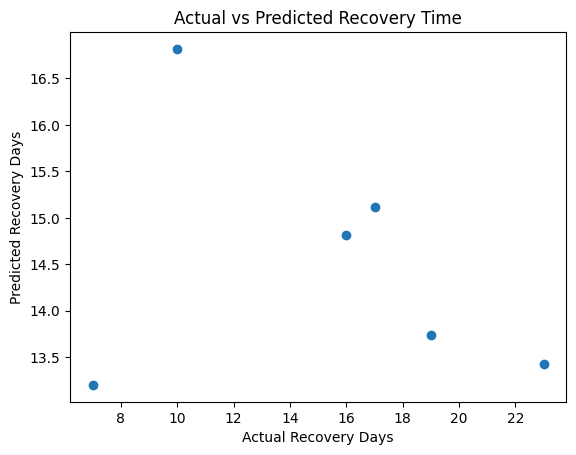

In [8]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Recovery Days")
plt.ylabel("Predicted Recovery Days")
plt.title("Actual vs Predicted Recovery Time")

plt.show()

Random Forest Model

In [9]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


Evaluate Random Forest

In [10]:
# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)
print("Random Forest MAE:", rf_mae)

Random Forest R2 Score: -1.6634155628499467
Random Forest MAE: 8.280765873015874


Feature Importance

In [11]:
# Feature importance
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

  Feature  Importance
0     age    0.877244
1     sex    0.122756


Plot Feature Importance

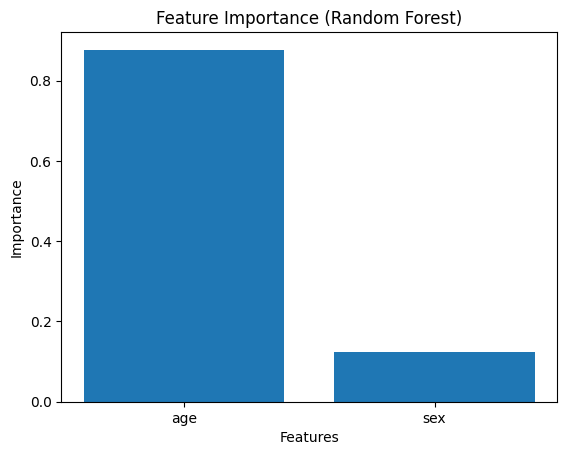

In [13]:
plt.figure()
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

Linear vs Random Forest Comparison

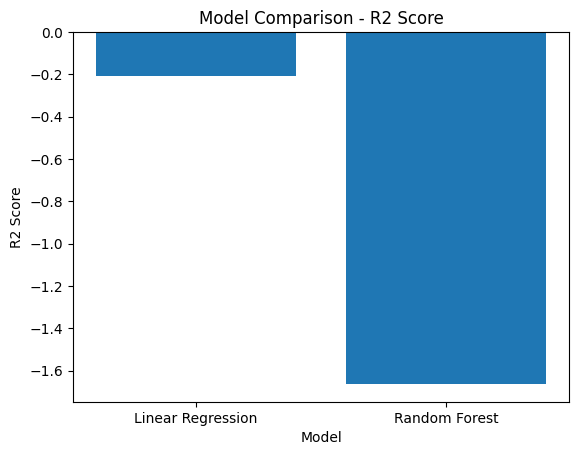

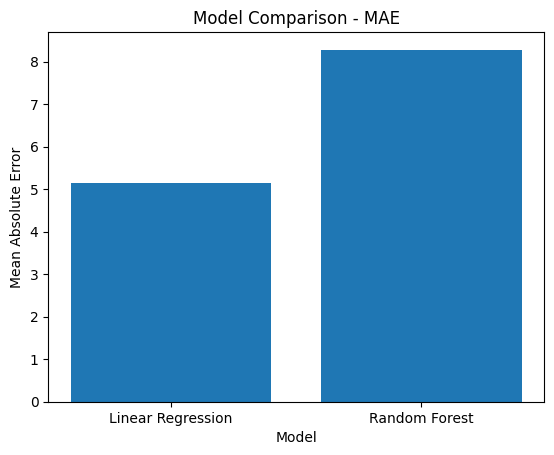

In [14]:
# Metrics
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2, rf_r2]
mae_scores = [mae, rf_mae]

x = np.arange(len(models))

# Plot R2 Score
plt.figure()
plt.bar(models, r2_scores)

plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()

# Plot MAE
plt.figure()
plt.bar(models, mae_scores)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.show()

Residual analysis

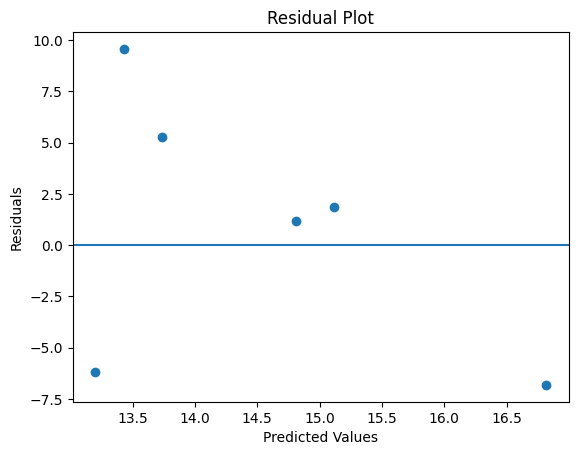

In [15]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)

plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()